# Flower Classification Notebook: ORB + XGBoost
This notebook implements the complete training and evaluation pipeline using real dataset inputs split into Train, Validation, and Test subsets.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

In [2]:
# Configurations
DATASET_DIR = "flower-training"
CLASSES = ["bellflower", "daisy", "dandelion", "lotus", "rose", "sunflower", "tulip"]
FEATURE_NAME = "ORB"
CLASSIFIER_NAME = "XGBoost"
# We set a default limit of 150 images per class for fast, crash-free execution in notebooks.
# Set LIMIT_PER_CLASS = None to run on the entire dataset.
LIMIT_PER_CLASS = 150


## 1. Image Preprocessing (3 Steps)
- **Step 1:** Resize image to $256 \times 256$ pixels.
- **Step 2:** Apply Gaussian Blur filter ($5 \times 5$ kernel).
- **Step 3:** Apply HSV-based Green color removal mask to extract the flower region.

In [3]:
def preprocess_single_image(img, targetedSize=(256, 256)):
    resized_img = cv2.resize(img, targetedSize, interpolation=cv2.INTER_LINEAR)
    blurred_img = cv2.GaussianBlur(resized_img, (5, 5), 0)
    return blurred_img

def extract_flower_mask(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower_green = np.array([18, 40, 40])
    upper_green = np.array([43, 255, 255])
    green_mask = cv2.inRange(hsv, lower_green, upper_green)
    flower_mask = cv2.bitwise_not(green_mask)
    return flower_mask

## 2. Feature Extraction
- Keypoint descriptor extractor (SIFT/ORB)
- HSV Color histogram feature extractor

In [4]:
class DescriptorService:
    def __init__(self):
        self.extractor = cv2.ORB_create(nfeatures=500)
        
    def extract_features(self, image, mask=None):
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image
        _, descriptors = self.extractor.detectAndCompute(gray, mask)
        if descriptors is None:
            return np.zeros((0, 32), dtype=np.float32)
        return descriptors.astype(np.float32)

def extract_hsv_histogram(image, mask=None):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], mask, [8, 4, 4], [0, 180, 0, 256, 0, 256])
    hist_flat = hist.flatten()
    norm = np.linalg.norm(hist_flat, ord=2)
    if norm > 0:
        hist_flat /= norm
    return hist_flat

## 3. Dataset Loading and Initial Splits
Load real images from the `flower-training` directory, preprocess them, and split into train/test.

In [5]:
print("Loading dataset...")
image_paths = []
labels = []

for label_idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(DATASET_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    count = 0
    for filename in os.listdir(cls_dir):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(cls_dir, filename))
            labels.append(label_idx)
            count += 1
            if LIMIT_PER_CLASS is not None and count >= LIMIT_PER_CLASS:
                break

print(f"Loaded {len(image_paths)} images from {len(CLASSES)} classes.")

# Split: Train (80%) and Test (20%)
X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

# Further split Train into Train (90% of Train) and Validation (10% of Train)
# This results in 72% Train, 8% Val, 20% Test of overall dataset
X_tr_paths, X_val_paths, y_tr, y_val = train_test_split(
    X_train_paths, y_train, test_size=0.1, stratify=y_train, random_state=42
)

print(f"Train size: {len(X_tr_paths)}, Val size: {len(X_val_paths)}, Test size: {len(X_test_paths)}")

Loading dataset...
Loaded 1050 images from 7 classes.
Train size: 756, Val size: 84, Test size: 210


## 4. Feature Extraction & BoVW Vocabulary Fitting
Fit K-Means vocabulary ONLY on the training descriptors, then compute fused BoVW + HSV Histograms for all subsets.

In [6]:
descriptor_service = DescriptorService()

def get_descriptors_and_colors(paths):
    descs_list = []
    colors_list = []
    for path in paths:
        img = cv2.imread(path)
        if img is None:
            descs_list.append(None)
            colors_list.append(np.zeros(128, dtype=np.float32))
            continue
        cleaned = preprocess_single_image(img)
        mask = extract_flower_mask(cleaned)
        descs = descriptor_service.extract_features(cleaned, mask=mask)
        color = extract_hsv_histogram(cleaned, mask=mask)
        descs_list.append(descs)
        colors_list.append(color)
    return descs_list, colors_list

print("Extracting training features...")
train_descs, train_colors = get_descriptors_and_colors(X_tr_paths)
print("Extracting validation features...")
val_descs, val_colors = get_descriptors_and_colors(X_val_paths)
print("Extracting test features...")
test_descs, test_colors = get_descriptors_and_colors(X_test_paths)

# Fit Visual Vocabulary (K-Means) on training descriptors
print("Fitting K-Means visual vocabulary...")
flat_train_descs = [d for d in train_descs if d is not None and len(d) > 0]
all_train_descs = np.vstack(flat_train_descs)
kmeans = MiniBatchKMeans(n_clusters=300, random_state=42, batch_size=1000, n_init="auto")
kmeans.fit(all_train_descs)

def fuse_features(descriptors, color_hist):
    # transform to vocabulary histogram
    histogram = np.zeros(300, dtype=np.float32)
    if descriptors is not None and len(descriptors) > 0:
        words = kmeans.predict(descriptors)
        for w in words:
            histogram[w] += 1.0
    norm1 = np.linalg.norm(histogram, ord=1)
    if norm1 > 0:
        histogram /= norm1
        
    # normalize color
    hist_l2 = histogram / (np.linalg.norm(histogram, ord=2) + 1e-6)
    color_l2 = color_hist / (np.linalg.norm(color_hist, ord=2) + 1e-6)
    
    # fuse
    fused = np.hstack([hist_l2, 0.5 * color_l2])
    fused /= np.linalg.norm(fused, ord=2) + 1e-6
    return fused

print("Fusing features...")
X_train_fused = np.array([fuse_features(train_descs[i], train_colors[i]) for i in range(len(X_tr_paths))])
X_val_fused = np.array([fuse_features(val_descs[i], val_colors[i]) for i in range(len(X_val_paths))])
X_test_fused = np.array([fuse_features(test_descs[i], test_colors[i]) for i in range(len(X_test_paths))])
y_train = np.array(y_tr)
y_val = np.array(y_val)
y_test = np.array(y_test)

Extracting training features...


Extracting validation features...


Extracting test features...


Fitting K-Means visual vocabulary...


Fusing features...


## 5. Model Training

In [7]:

# Train XGBoost model with regularization to prevent overfitting
print("Training XGBoost Classifier...")
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=2.0,
    reg_lambda=2.0,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train_fused, y_train,
    eval_set=[(X_train_fused, y_train), (X_val_fused, y_val)],
    verbose=False
)


Training XGBoost Classifier...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

## 6. Model Evaluation
Print classification report and plot confusion matrix.

--- Classification Report: ORB + XGBoost ---
              precision    recall  f1-score   support

  bellflower       0.81      0.83      0.82        30
       daisy       0.64      0.60      0.62        30
   dandelion       0.67      0.67      0.67        30
       lotus       0.76      0.63      0.69        30
        rose       0.59      0.63      0.61        30
   sunflower       0.70      0.87      0.78        30
       tulip       0.63      0.57      0.60        30

    accuracy                           0.69       210
   macro avg       0.69      0.69      0.68       210
weighted avg       0.69      0.69      0.68       210



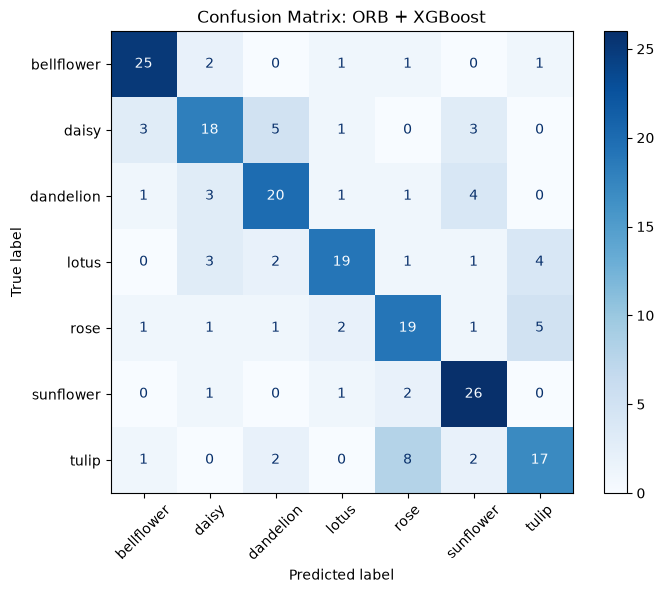

In [8]:
preds = model.predict(X_test_fused)
print(f"--- Classification Report: {FEATURE_NAME} + {CLASSIFIER_NAME} ---")
print(classification_report(y_test, preds, target_names=CLASSES))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title(f"Confusion Matrix: {FEATURE_NAME} + {CLASSIFIER_NAME}")
plt.show()

## 7. Iterative Training: Accuracy and Loss Curves

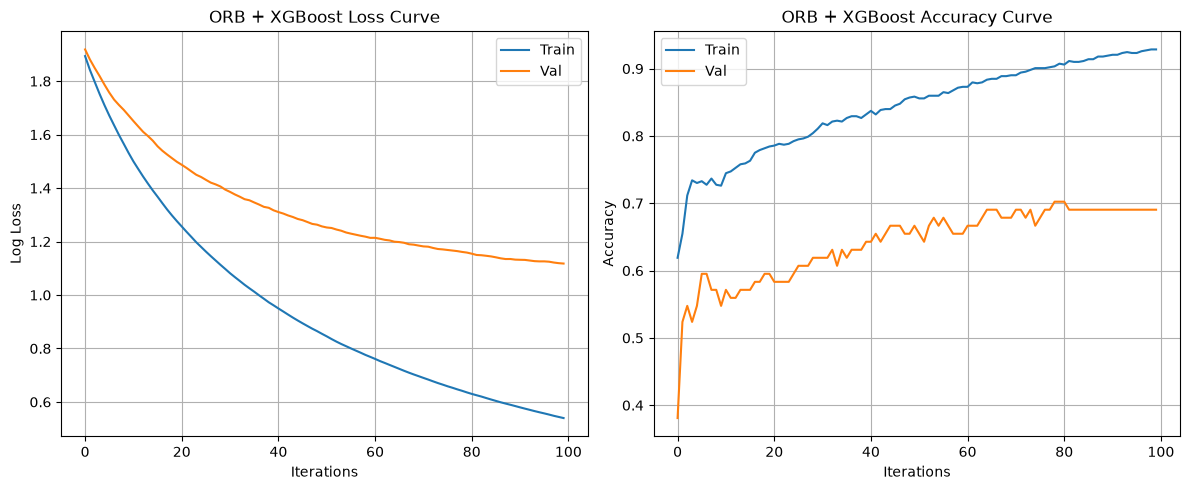

In [9]:

# Plot LogLoss Learning Curves from training history
results = model.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(12, 5))

# Plot Log Loss
plt.subplot(1, 2, 1)
plt.plot(results['validation_0']['mlogloss'], label='Train')
plt.plot(results['validation_1']['mlogloss'], label='Val')
plt.legend()
plt.ylabel('Log Loss')
plt.xlabel('Iterations')
plt.title(f'{FEATURE_NAME} + {CLASSIFIER_NAME} Loss Curve')
plt.grid(True)

# Plot accuracy iteration progress
train_accs = []
val_accs = []
for i in range(1, epochs + 1):
    train_preds = model.predict(X_train_fused, iteration_range=(0, i))
    val_preds = model.predict(X_val_fused, iteration_range=(0, i))
    train_accs.append(np.mean(train_preds == y_train))
    val_accs.append(np.mean(val_preds == y_val))

plt.subplot(1, 2, 2)
plt.plot(x_axis, train_accs, label='Train')
plt.plot(x_axis, val_accs, label='Val')
plt.legend()
plt.ylabel('Accuracy')
plt.xlabel('Iterations')
plt.title(f'{FEATURE_NAME} + {CLASSIFIER_NAME} Accuracy Curve')
plt.grid(True)

plt.tight_layout()
plt.show()


## 8. Learning Curves
Shows training and validation accuracy vs. size of dataset subset.

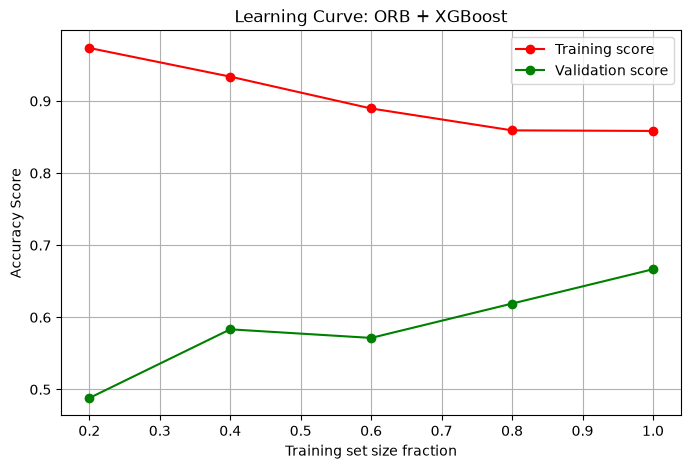

In [10]:
train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
lc_train = []
lc_val = []

for size in train_sizes:
    n_samples = int(size * len(X_train_fused))
    if n_samples < 10:
        n_samples = 10
    X_sub = X_train_fused[:n_samples]
    y_sub = y_train[:n_samples]
    
    if CLASSIFIER_NAME == "RandomForest":
        clf = RandomForestClassifier(
            n_estimators=50,
            max_depth=8,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    else:
        clf = XGBClassifier(
            n_estimators=50,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.7,
            colsample_bytree=0.7,
            reg_alpha=2.0,
            reg_lambda=2.0,
            eval_metric='mlogloss',
            random_state=42,
            n_jobs=-1
        )
        
    clf.fit(X_sub, y_sub)
    lc_train.append(clf.score(X_sub, y_sub))
    lc_val.append(clf.score(X_val_fused, y_val))

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, lc_train, 'o-', color="r", label="Training score")
plt.plot(train_sizes, lc_val, 'o-', color="g", label="Validation score")
plt.title(f"Learning Curve: {FEATURE_NAME} + {CLASSIFIER_NAME}")
plt.xlabel("Training set size fraction")
plt.ylabel("Accuracy Score")
plt.grid(True)
plt.legend()
plt.show()